# Data Visualization using the 3W Toolkit

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ThreeWToolkit.data_visualization import DataVisualization
from ThreeWToolkit.dataset import ParquetDatasetConfig

np.random.seed(42)

# Series

### Time Series Visualization with `plot_series`

This section demonstrates how to use the `plot_series` method from the `DataVisualization` class to visualize time series data, including:

- Random time series,
- Trends,
- Seasonality and noise,
- Missing values (events).

The function returns a `matplotlib.figure.Figure` object and is useful for exploratory data analysis and visual 

#### Example 1: Random Time Series

/tmp/ipykernel_51081/81706836.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


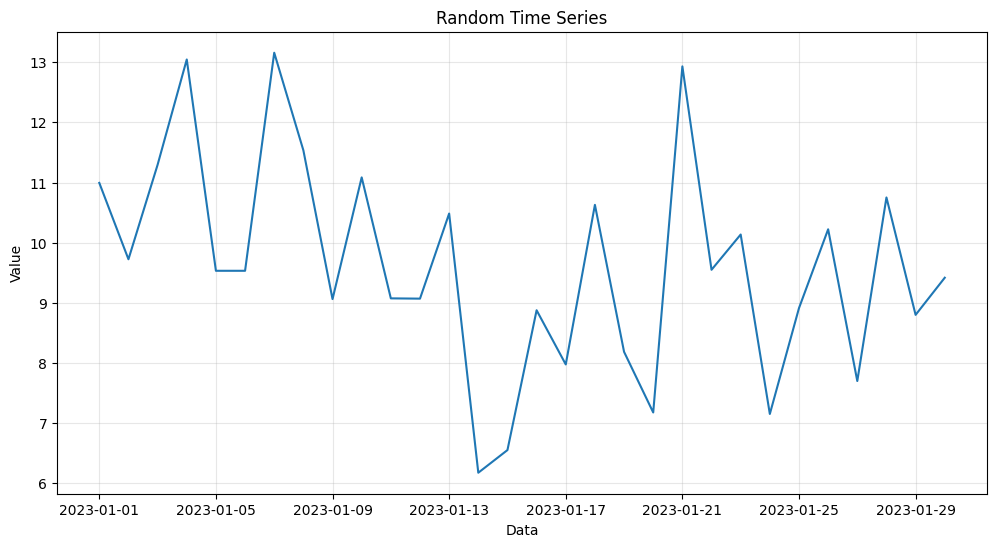

In [ ]:
dates = pd.date_range("2023-01-01", periods=30, freq="D")
values = np.random.normal(loc=10, scale=2, size=30)
series = pd.Series(values, index=dates)

fig, _ = DataVisualization.plot_series(
    series=series,
    title="Random Time Series",
    xlabel="Data",
    ylabel="Value",
    overlay_events=False,
)
fig.show()

#### Example 2: Using plot_series with multiple subplots (ax provided)

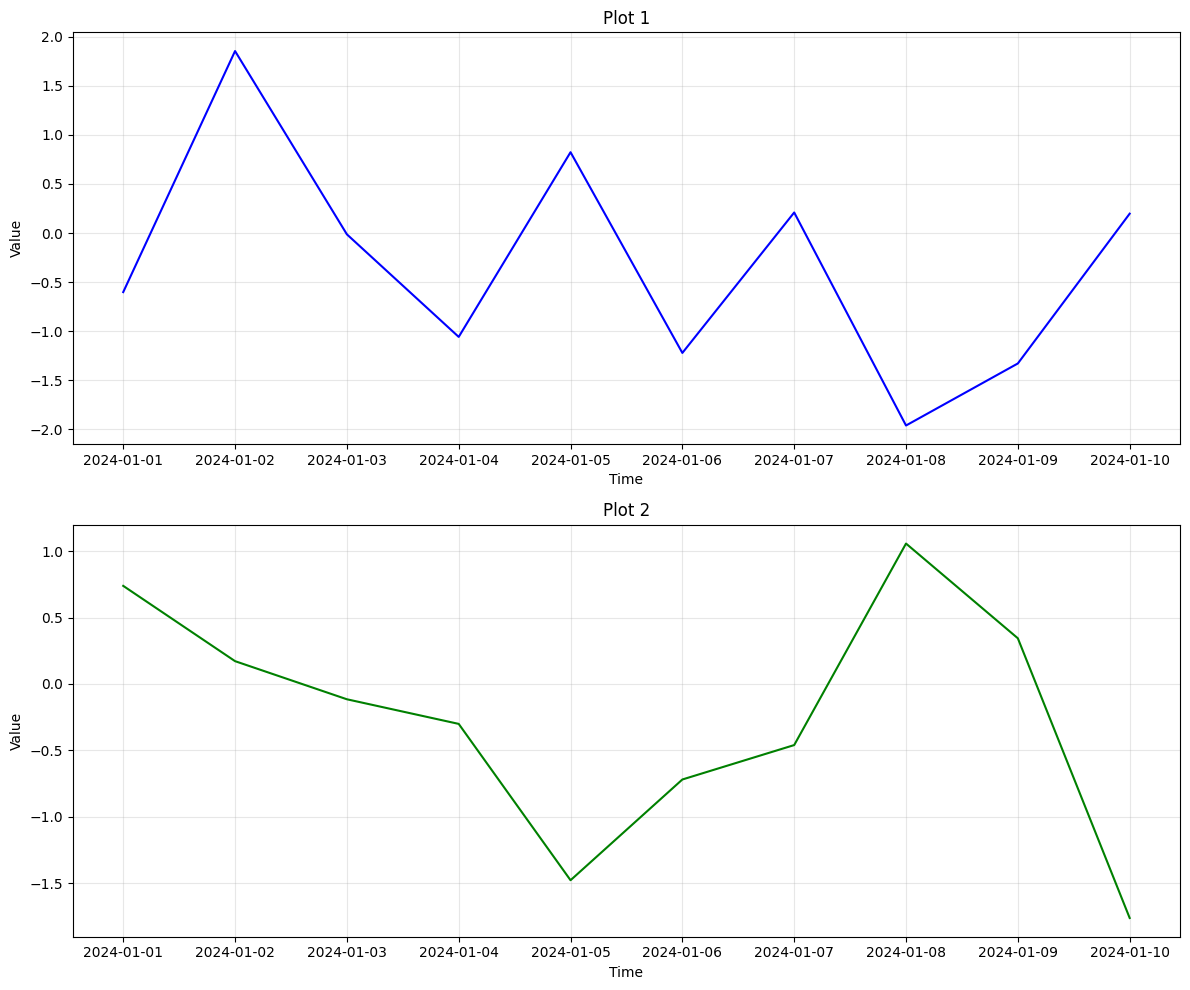

In [16]:
# Create two sample series
dates = pd.date_range("2024-01-01", periods=10)
series1 = pd.Series(np.random.randn(10), index=dates)
series2 = pd.Series(np.random.randn(10), index=dates)

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Use plot_series with specified Axes
DataVisualization.plot_series(
    series1, "Plot 1", "Time", "Value", ax=axs[0], color="blue"
)
DataVisualization.plot_series(
    series2, "Plot 2", "Time", "Value", ax=axs[1], color="green"
)

plt.tight_layout()
plt.show()

#### Example 3: Using 3W data - Simple Time Series Plot

In [17]:
ds = ParquetDatasetConfig(path="../../dataset").build()
print(f"Dataset length: {len(ds)}")
sig = ds[123].signal.copy()

2026-04-06 16:04:50,436 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-06 16:04:50,437 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-06 16:04:50,439 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Dataset length: 2228


/tmp/ipykernel_51081/1911898133.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


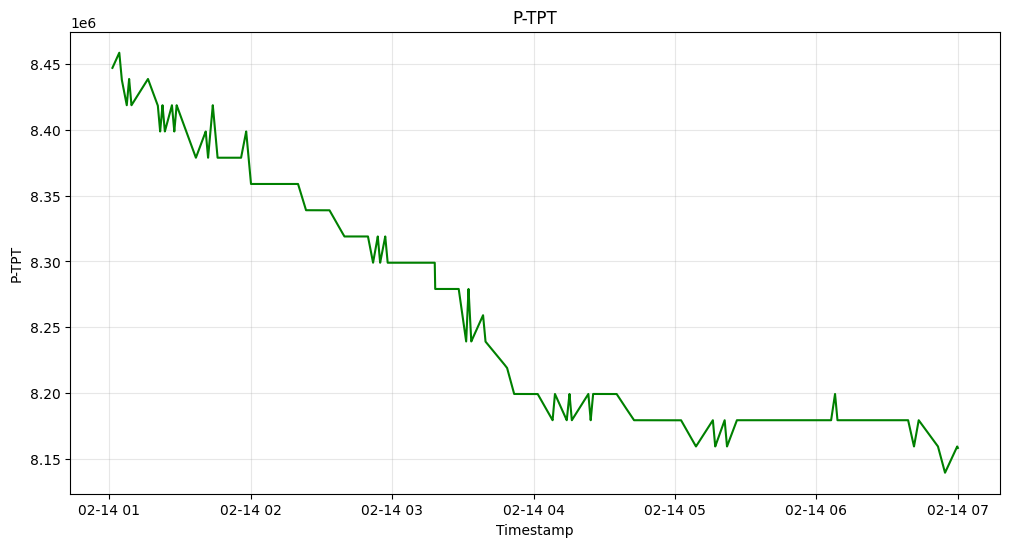

In [18]:
series = sig["P-TPT"]
fig, _ = DataVisualization.plot_series(
    series=series,
    title="P-TPT",
    xlabel="Timestamp",
    ylabel="P-TPT",
    overlay_events=False,
    color="green",
)
fig.show()

#### Example 4: Using 3W data - Using plot_series with multiple subplots (ax provided)

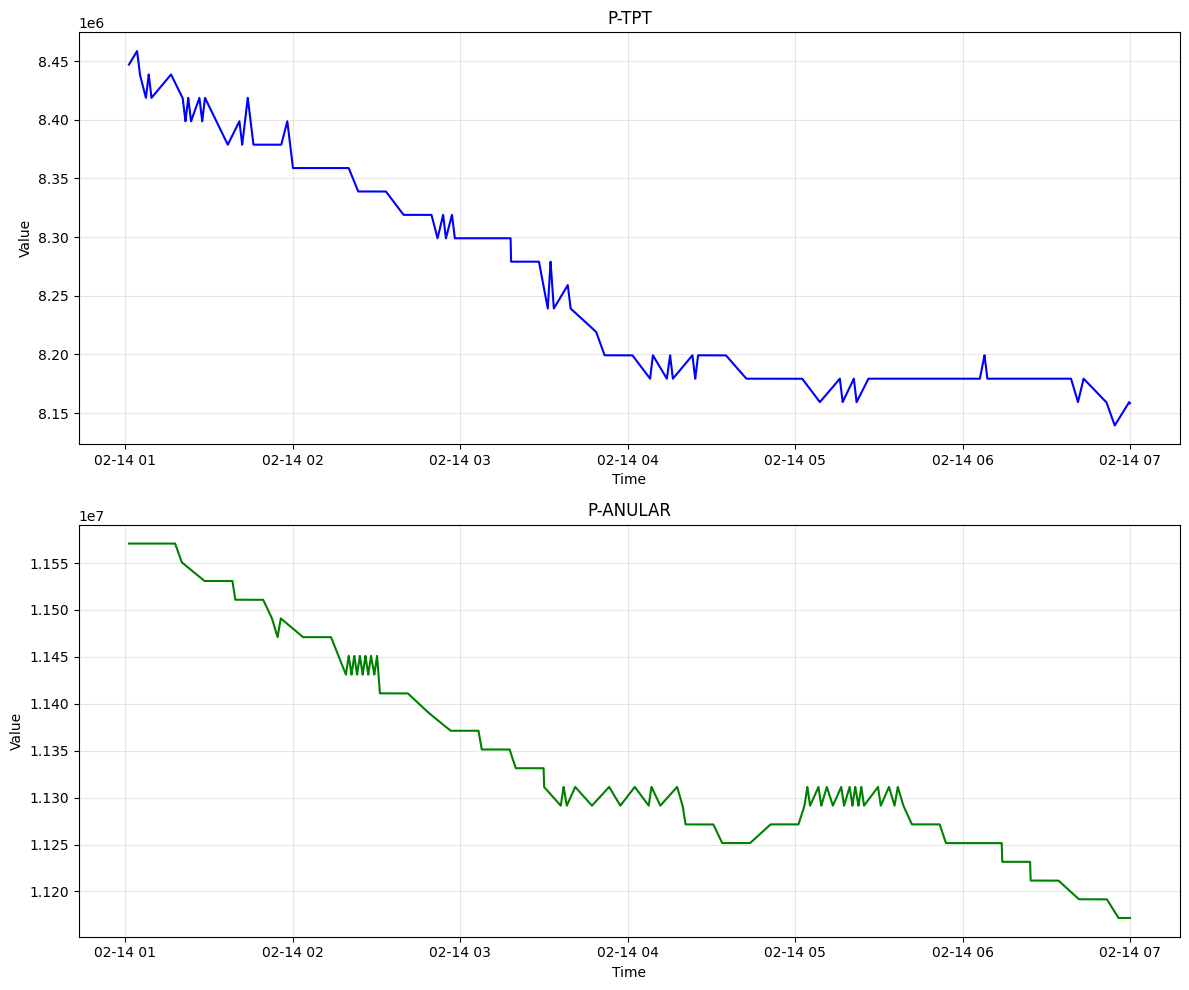

In [19]:
series_P_TPT = sig["P-TPT"]
series_P_ANULAR = sig["P-ANULAR"]

# create subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# use plot_series with specified Axes
DataVisualization.plot_series(
    series_P_TPT, "P-TPT", "Time", "Value", ax=axs[0], color="blue"
)
DataVisualization.plot_series(
    series_P_ANULAR, "P-ANULAR", "Time", "Value", ax=axs[1], color="green"
)

plt.tight_layout()
plt.show()

### Example 5: Using 3W data - Time Series with Missing Values

We introduce some missing values (`NaN`) at specific positions. When `overlay_events=True`, the function overlays vertical dashed lines to highlight these missing data points — useful for anomaly or outage detection.

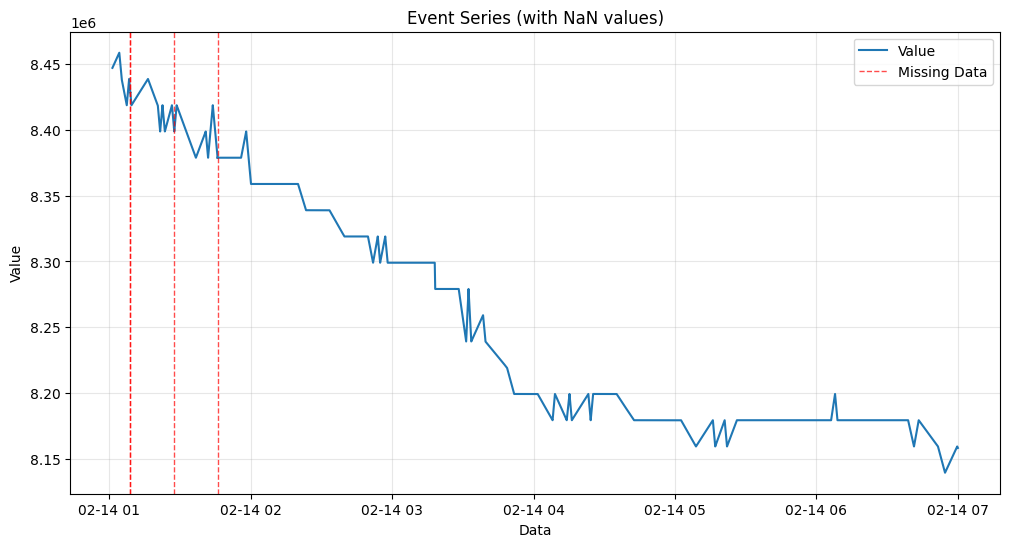

In [20]:
series_P_TPT = sig["P-TPT"].copy()
series_P_TPT.iloc[[456, 1567, 2678]] = np.nan  # adding NaNs

fig = DataVisualization.plot_series(
    series=series_P_TPT,
    title="Event Series (with NaN values)",
    xlabel="Data",
    ylabel="Value",
    overlay_events=True,
)
plt.show()

# Multiple Series

This section demonstrates how to use the `plot_multiple_series` method from the `DataVisualization` class to visualize time series data, including:

- Simple usage with multiple time series,
- Using subplots for different groups,
- Trends, Seasonality and noise,
- Missing values (events).

The function returns a `matplotlib.figure.Figure` object and is useful for exploratory data analysis and visual reports.

#### Example 1: Simple usage with multiple time series

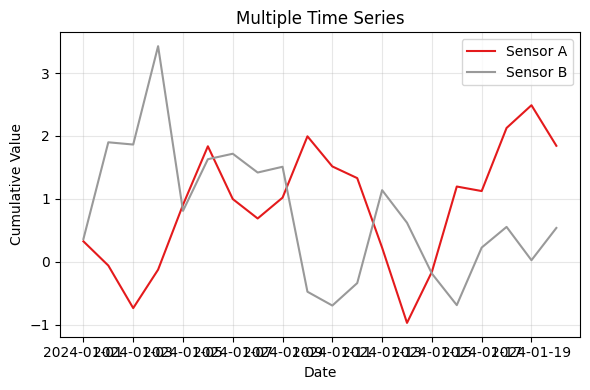

In [21]:
# Create example time series
dates = pd.date_range("2024-01-01", periods=20)
series_a = pd.Series(np.random.randn(20).cumsum(), index=dates)
series_b = pd.Series(np.random.randn(20).cumsum(), index=dates)

# Create subplots
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

DataVisualization.plot_multiple_series(
    series_list=[series_a, series_b],
    labels=["Sensor A", "Sensor B"],
    title="Multiple Time Series",
    xlabel="Date",
    ylabel="Cumulative Value",
    ax=axs,
)

plt.tight_layout()
plt.show()

#### Example 2: Using subplots for different groups

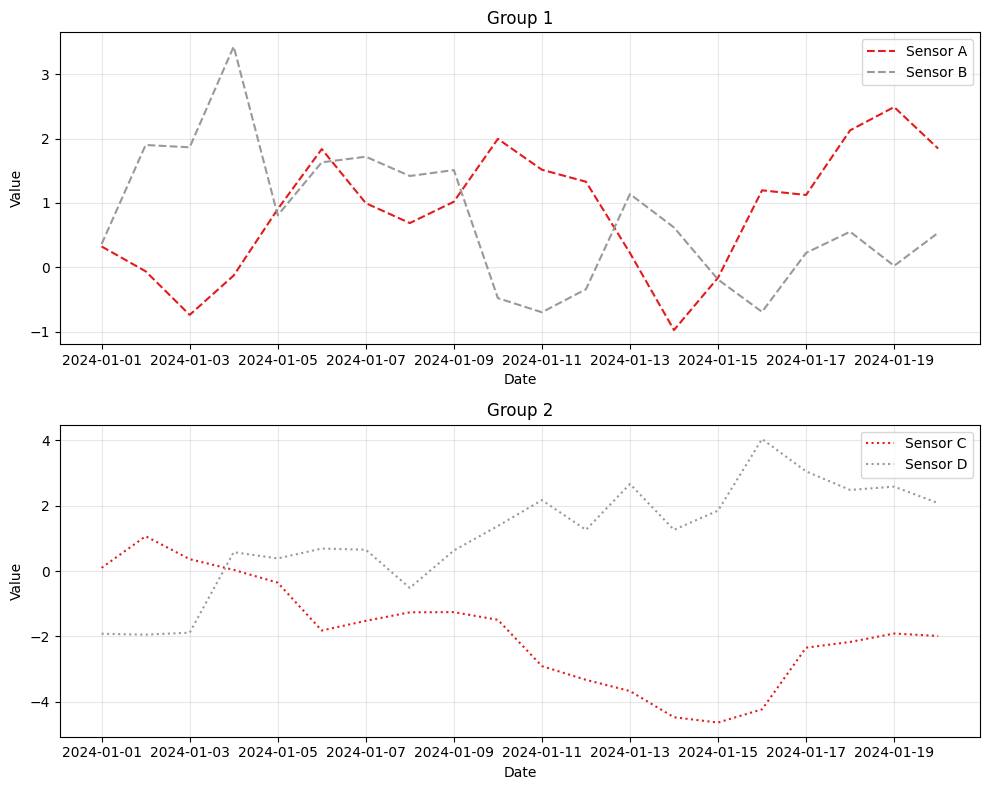

In [22]:
# Create more time series
series_c = pd.Series(np.random.randn(20).cumsum(), index=dates)
series_d = pd.Series(np.random.randn(20).cumsum(), index=dates)

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# First plot: A and B
DataVisualization.plot_multiple_series(
    series_list=[series_a, series_b],
    labels=["Sensor A", "Sensor B"],
    title="Group 1",
    xlabel="Date",
    ylabel="Value",
    ax=axs[0],
    linestyle="--",
)

# Second plot: C and D
DataVisualization.plot_multiple_series(
    series_list=[series_c, series_d],
    labels=["Sensor C", "Sensor D"],
    title="Group 2",
    xlabel="Date",
    ylabel="Value",
    ax=axs[1],
    linestyle=":",
)

plt.tight_layout()
plt.show()

#### Example 3: Using 3W Data - Simple usage with multiple time series

We generate a random time series with daily frequency. The `plot_multiple_series` method is used to display the values with a custom title and labeled axes.

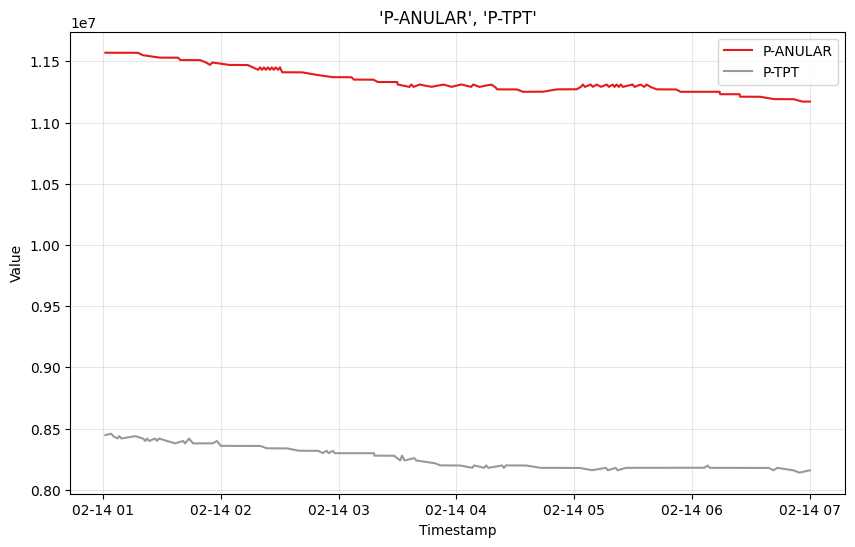

In [23]:
series_list = [sig["P-ANULAR"], sig["P-TPT"]]

fig, axs = plt.subplots(1, 1, figsize=(10, 6))
fig, _ = DataVisualization.plot_multiple_series(
    series_list=series_list,
    labels=["P-ANULAR", "P-TPT"],
    title="'P-ANULAR', 'P-TPT'",
    xlabel="Timestamp",
    ylabel="Value",
    ax=axs,
)
plt.show()

#### Example 4: Using 3W Data - Using subplots for different groups

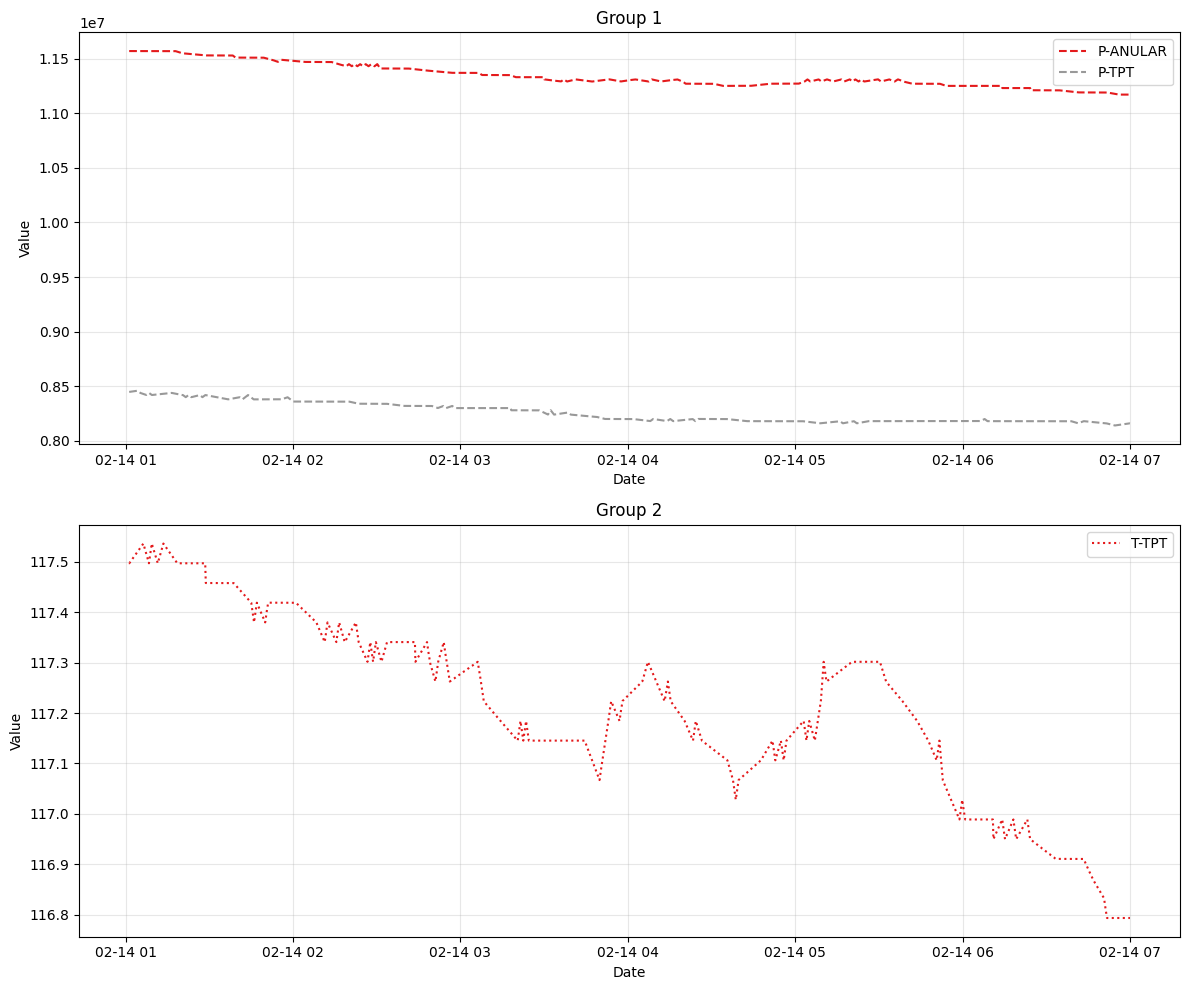

In [24]:
series_list_group1 = [sig["P-ANULAR"], sig["P-TPT"]]
series_list_group2 = [sig["T-TPT"]]


fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# First plot: A and B
DataVisualization.plot_multiple_series(
    series_list=series_list_group1,
    labels=["P-ANULAR", "P-TPT"],
    title="Group 1",
    xlabel="Date",
    ylabel="Value",
    ax=axs[0],
    linestyle="--",
)

# Second plot: C and D
DataVisualization.plot_multiple_series(
    series_list=series_list_group2,
    labels=["T-TPT"],
    title="Group 2",
    xlabel="Date",
    ylabel="Value",
    ax=axs[1],
    linestyle=":",
)

plt.tight_layout()
plt.show()

The `plot_multiple_series` method provides a clean and reusable way to visualize time series with:

- Custom titles and axis labels,
- Event overlays for missing values,
- Full support for `pandas.Series` with datetime indices.

This makes it a practical tool for time series forecasting, anomaly detection, and reporting in real-world pipelines.

# Heatmap

### Correlation Heatmap Demonstration

This notebook demonstrates how to use the `DataVisualization.correlation_heatmap` function in various scenarios.

The function accepts:
- A DataFrame of time series (`df_of_series`)
- Additional keyword arguments (`**kwargs`) for customization (e.g., `title`, `figsize`, `annot`, `cmap`, `ax`, etc.)

#### Example 1: Basic Usage

/tmp/ipykernel_51081/1487946060.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


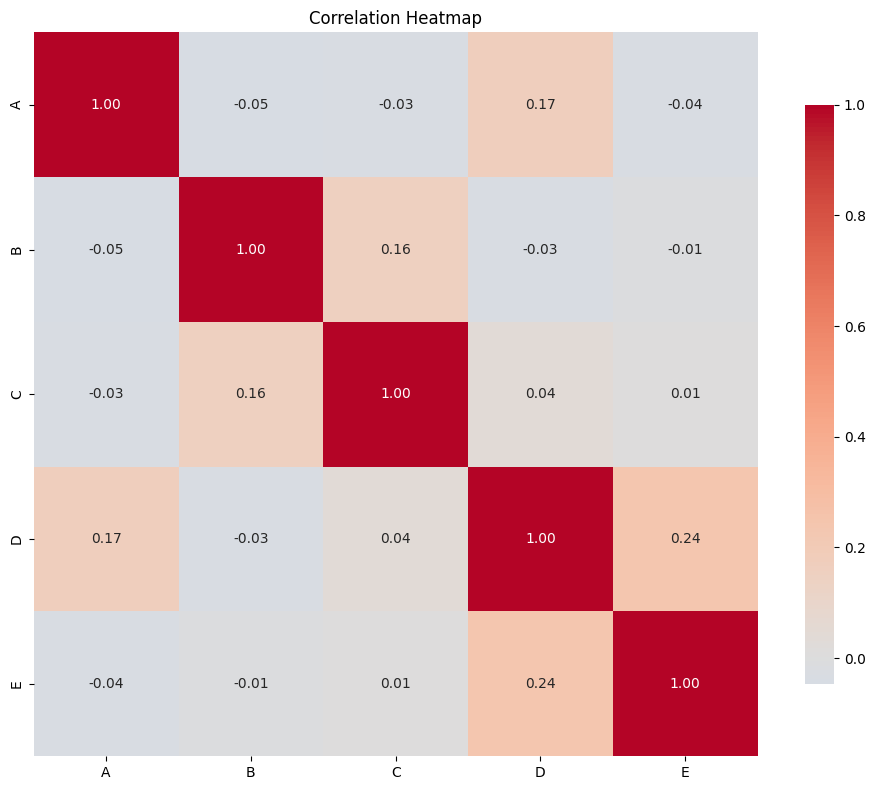

In [25]:
df = pd.DataFrame(np.random.rand(100, 5), columns=["A", "B", "C", "D", "E"])
fig, _ = DataVisualization.correlation_heatmap(df)
fig.show()

#### Example 2: Custom Title and Annotations

/tmp/ipykernel_51081/2754938477.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


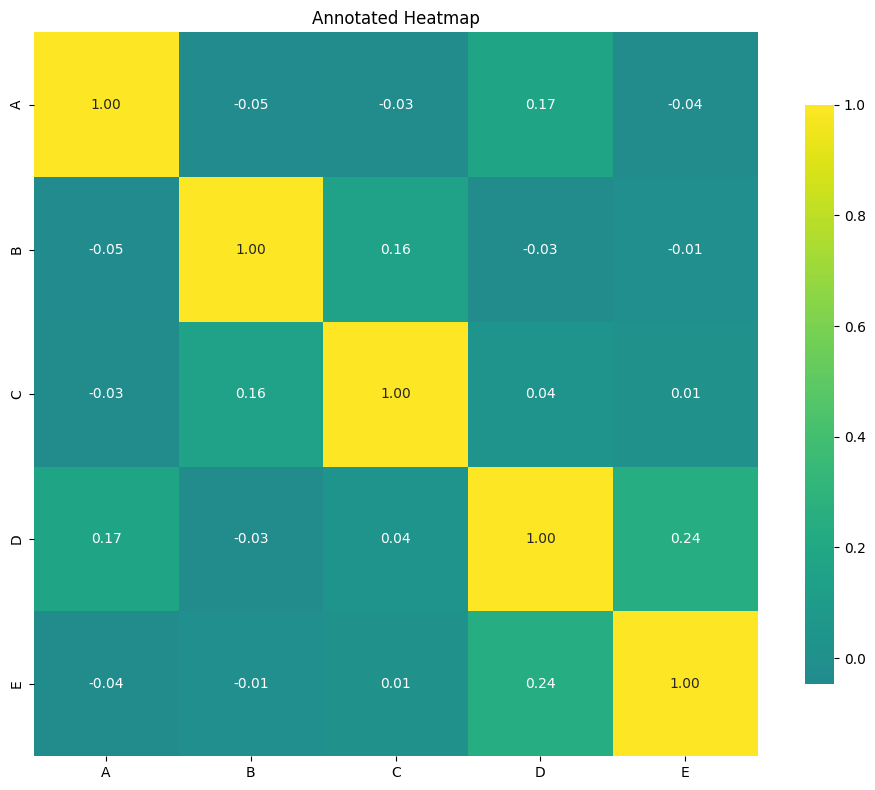

In [26]:
fig, _ = DataVisualization.correlation_heatmap(
    df, title="Annotated Heatmap", annot=True, cmap="viridis", fmt=".2f"
)
fig.show()

#### Example 3: Multiple Heatmaps in Subplots

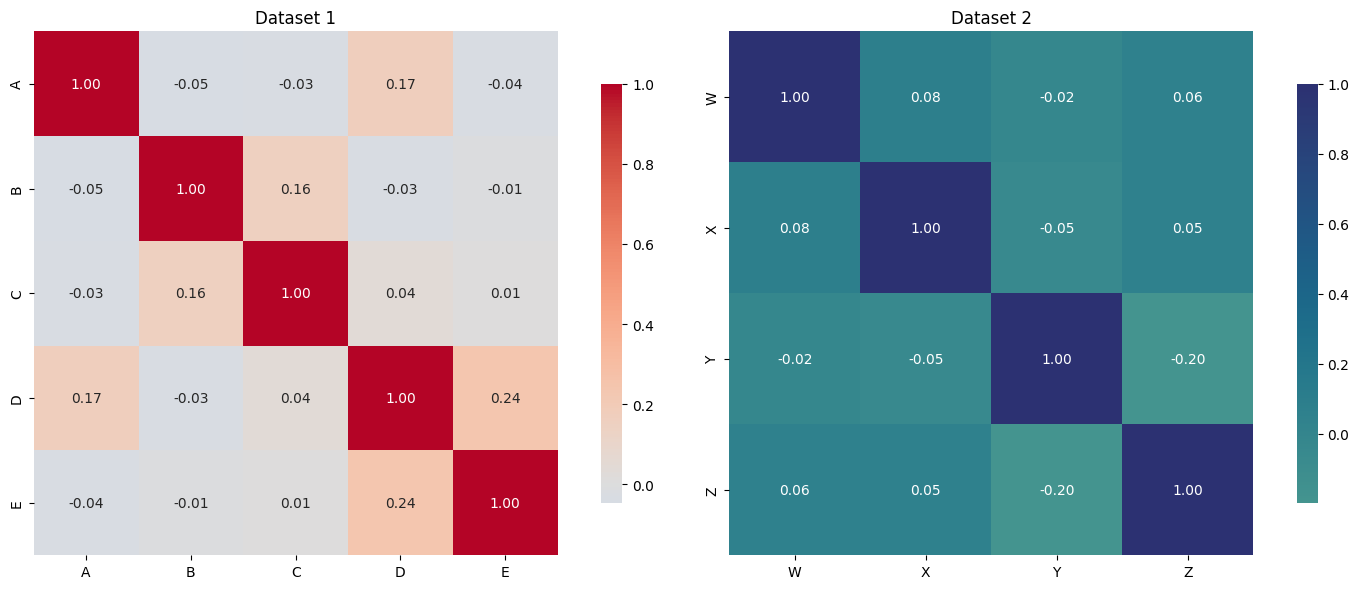

In [27]:
df2 = pd.DataFrame(np.random.rand(100, 4), columns=["W", "X", "Y", "Z"])

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
DataVisualization.correlation_heatmap(df, ax=axs[0], title="Dataset 1", annot=True)
DataVisualization.correlation_heatmap(
    df2, ax=axs[1], title="Dataset 2", cmap="crest", annot=True
)
plt.tight_layout()
plt.show()

#### Example 4: Using 3W data - Basic Usage

/tmp/ipykernel_51081/2170412813.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


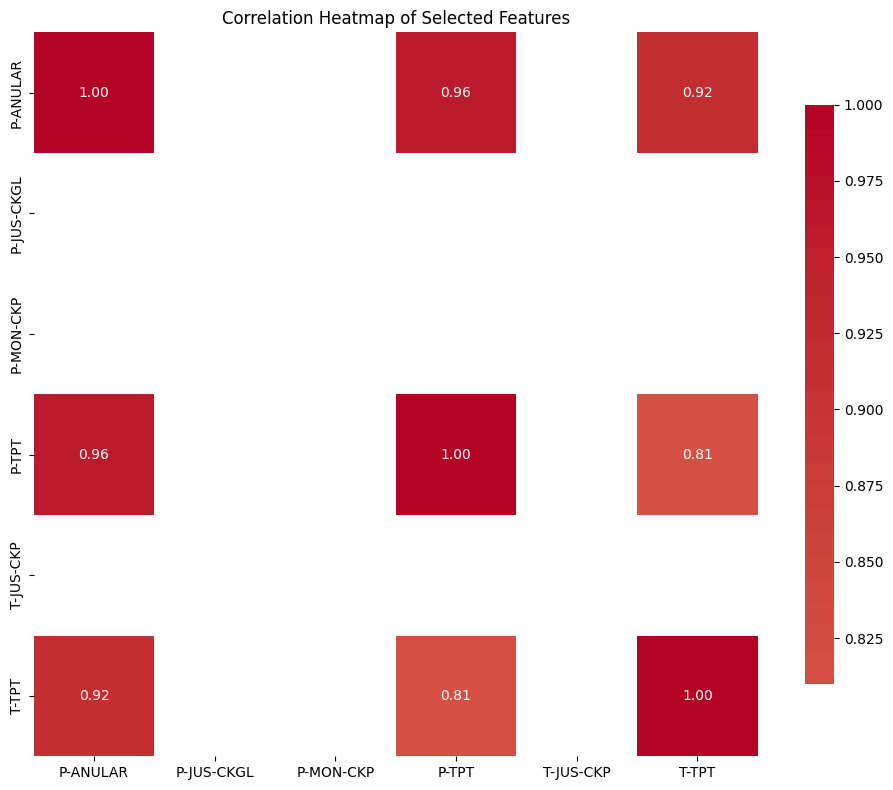

In [28]:
features = ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
subset = sig[features]

fig, _ = DataVisualization.correlation_heatmap(
    df_of_series=subset, title="Correlation Heatmap of Selected Features"
)
fig.show()

#### Example 5: Using 3W data - Custom Title and Annotations

/tmp/ipykernel_51081/1205364533.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


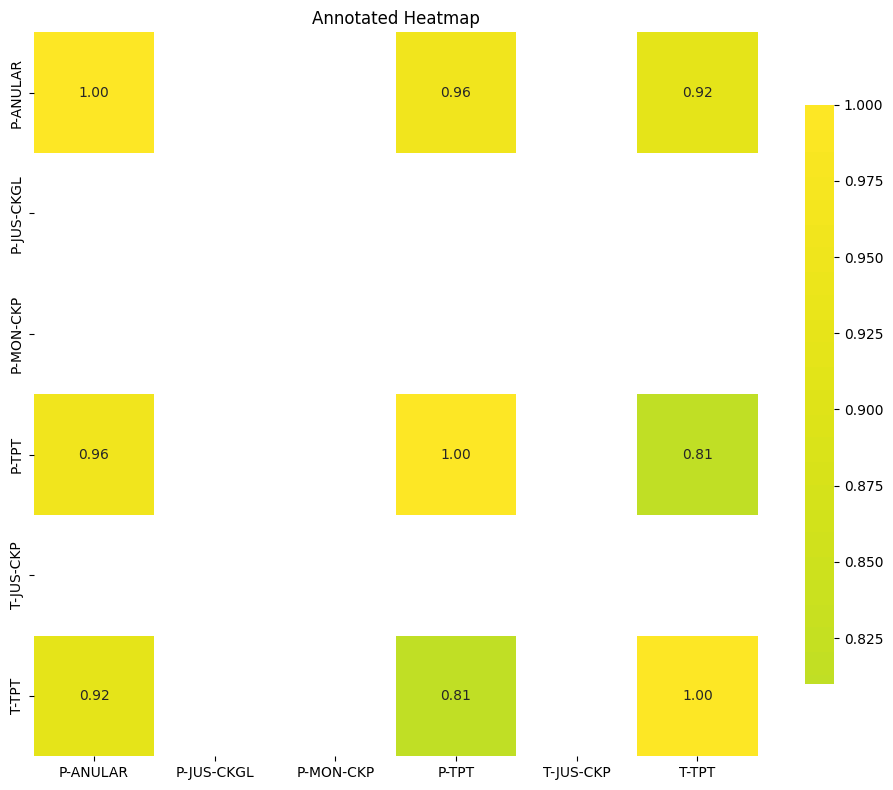

In [29]:
features = ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
subset = sig[features]

fig, _ = DataVisualization.correlation_heatmap(
    subset, title="Annotated Heatmap", annot=True, cmap="viridis", fmt=".2f"
)
fig.show()

#### Example 6: Using 3W data - Custom Figure Size and Color Map

/tmp/ipykernel_51081/2212497628.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


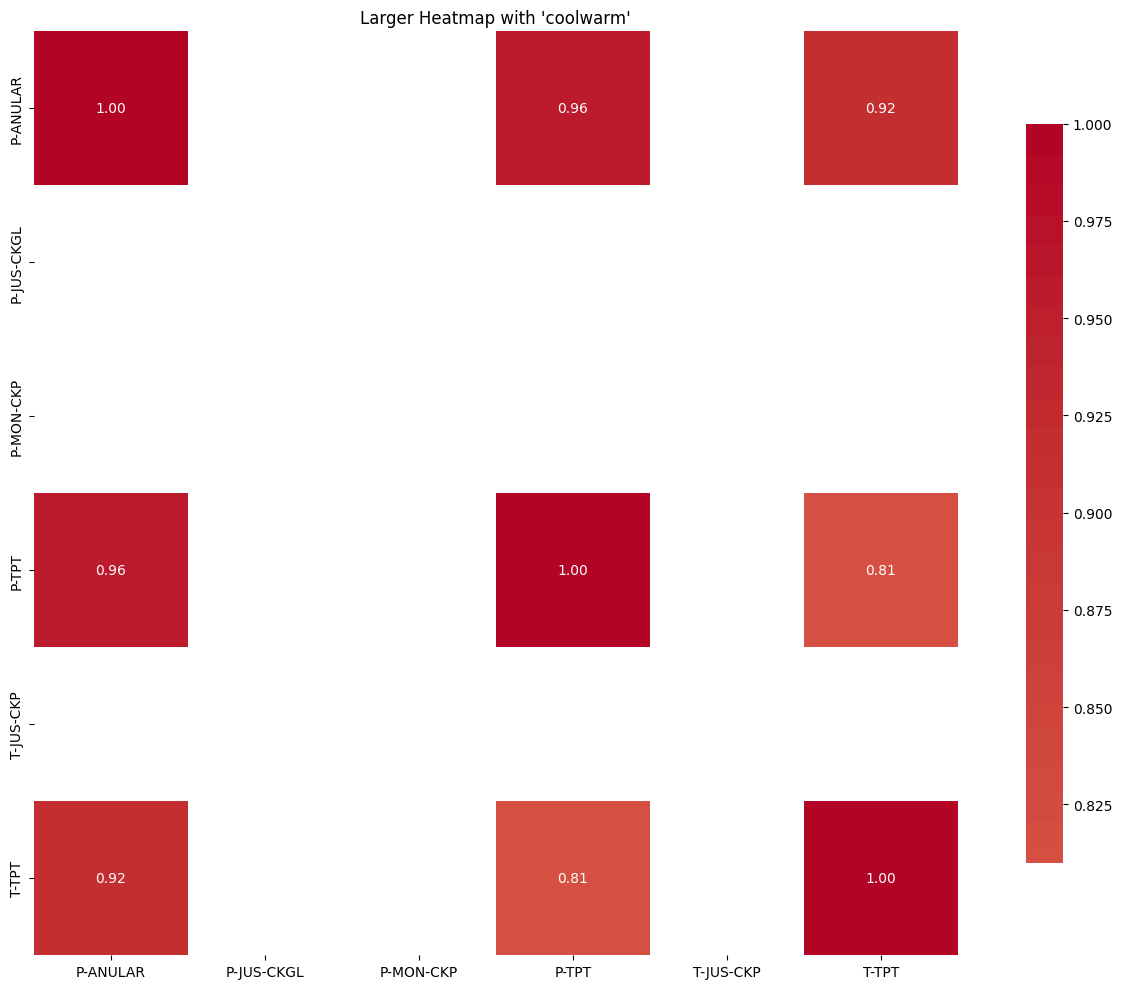

In [30]:
features = ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
subset = sig[features]

fig, _ = DataVisualization.correlation_heatmap(
    subset,
    title="Larger Heatmap with 'coolwarm'",
    figsize=(14, 10),
    cmap="coolwarm",
    annot=True,
)
fig.show()